In [6]:
import tensorflow as tf
print(tf.__version__)


2.16.1


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import precision_score, recall_score

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

# Load cleaned signals
X = np.load('bragg_signals_cleaned.npy')
y = np.load('bragg_labels.npy')

print(f"Signals shape : {X.shape}")
print(f"Labels shape  : {y.shape}")

TensorFlow version: 2.16.1
Signals shape : (6000, 300)
Labels shape  : (6000,)


In [11]:
# Split normal vs anomaly
X_normal  = X[y == 'normal']
X_anomaly = X[y != 'normal']
y_anomaly = y[y != 'normal']

# 80% train, 20% validation (all normal)
split     = int(0.8 * len(X_normal))
X_train   = X_normal[:split]
X_val     = X_normal[split:]

print(f"Train (normal only) : {X_train.shape}")
print(f"Validation (normal) : {X_val.shape}")
print(f"Anomaly test set    : {X_anomaly.shape}")

# Downsample: take every 3rd point (300 → 100 timesteps)
# Same shape information, 3x faster training
X_train_3d   = X_train[:, ::3].reshape(-1, 100, 1)
X_val_3d     = X_val[:, ::3].reshape(-1, 100, 1)
X_anomaly_3d = X_anomaly[:, ::3].reshape(-1, 100, 1)

print(f"Downsampled shape: {X_train_3d.shape}")
print("100 timesteps is enough to capture all peak features")

Train (normal only) : (4000, 300)
Validation (normal) : (1000, 300)
Anomaly test set    : (1000, 300)
Downsampled shape: (4000, 100, 1)
100 timesteps is enough to capture all peak features


In [13]:
def build_lstm_autoencoder(timesteps=100, features=1):
    inputs  = keras.Input(shape=(timesteps, features))
    x       = layers.LSTM(32, activation='tanh',
                          return_sequences=False)(inputs)
    x       = layers.RepeatVector(timesteps)(x)
    x       = layers.LSTM(32, activation='tanh',
                          return_sequences=True)(x)
    outputs = layers.TimeDistributed(layers.Dense(1))(x)
    model   = keras.Model(inputs, outputs)
    return model

model = build_lstm_autoencoder()
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 100, 1)         │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_3d, X_train_3d,
    epochs=30,               # reduced from 50
    batch_size=128,          # increased from 64 → faster
    validation_data=(X_val_3d, X_val_3d),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 396ms/step - loss: 0.0486 - val_loss: 0.0368
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 281ms/step - loss: 0.0368 - val_loss: 0.0365
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - loss: 0.0364 - val_loss: 0.0359
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 279ms/step - loss: 0.0359 - val_loss: 0.0358
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 316ms/step - loss: 0.0358 - val_loss: 0.0357
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - loss: 0.0358 - val_loss: 0.0357
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - loss: 0.0357 - val_loss: 0.0356
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 276ms/step - loss: 0.0357 - val_loss: 0.0356
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - loss: 0.0356 - val_loss: 0.0355
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 281ms/step - loss: 0.0356 - val_loss: 0.0355
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 313ms/step - loss: 0.0356 - val_loss: 0.0355
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms

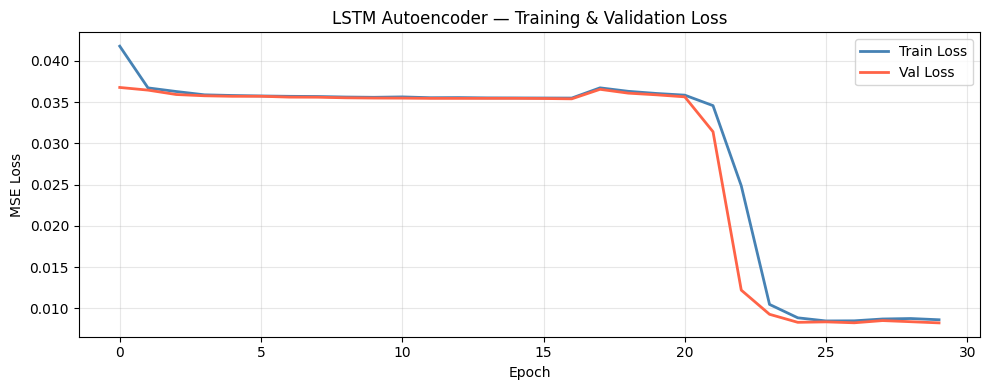

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],
         label='Train Loss', color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'],
         label='Val Loss', color='tomato', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Autoencoder — Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Normal signal reconstruction errors:
  Mean      : 0.008229
  Std       : 0.005003
  95th pct  : 0.017078

🎯 Anomaly threshold: 0.017078


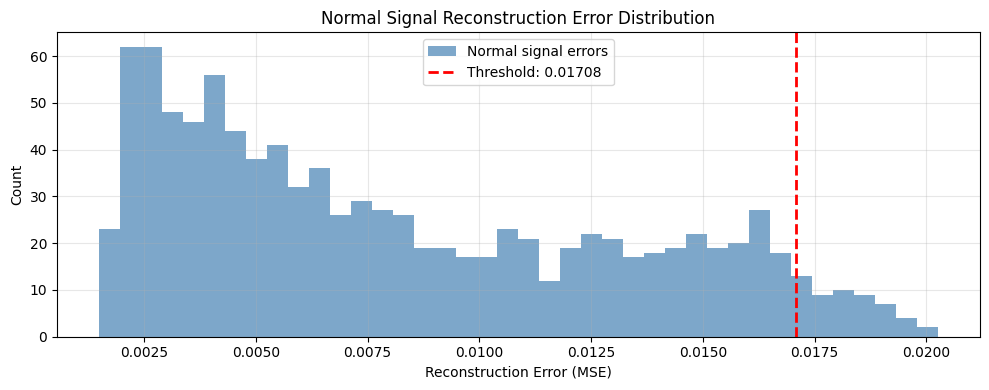

In [16]:
# Reconstruction error on normal validation signals
val_recon  = model.predict(X_val_3d, verbose=0)
val_errors = np.mean(np.power(X_val_3d - val_recon, 2), 
                     axis=(1, 2))

# Threshold = 95th percentile of normal errors
threshold = np.percentile(val_errors, 95)

print(f"Normal signal reconstruction errors:")
print(f"  Mean      : {val_errors.mean():.6f}")
print(f"  Std       : {val_errors.std():.6f}")
print(f"  95th pct  : {threshold:.6f}")
print(f"\n🎯 Anomaly threshold: {threshold:.6f}")

# Plot error distribution
plt.figure(figsize=(10, 4))
plt.hist(val_errors, bins=40, color='steelblue',
         alpha=0.7, label='Normal signal errors')
plt.axvline(threshold, color='red', linestyle='--',
            linewidth=2, label=f'Threshold: {threshold:.5f}')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Normal Signal Reconstruction Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Reconstruction errors for anomaly signals
anom_recon  = model.predict(X_anomaly_3d, verbose=0)
anom_errors = np.mean(np.power(X_anomaly_3d - anom_recon, 2),
                      axis=(1, 2))

# Flag as anomaly if error > threshold
y_pred = (anom_errors > threshold).astype(int)
y_true = np.ones(len(anom_errors))

precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = 2 * precision * recall / (precision + recall + 1e-9)

print("LSTM Autoencoder — Results")
print("=" * 42)
print(f"Anomalies detected : {y_pred.sum()} / {len(y_pred)}")
print(f"Precision          : {precision*100:.2f}%")
print(f"Recall             : {recall*100:.2f}%")
print(f"F1-Score           : {f1*100:.2f}%")

print("\nDetection rate per anomaly type:")
for atype in ['range_shift', 'amplitude_drop',
              'scatter_artifact', 'missing_peak']:
    mask     = y_anomaly == atype
    detected = (anom_errors[mask] > threshold).sum()
    total    = mask.sum()
    print(f"  {atype:<20}: {detected}/{total} "
          f"({detected/total*100:.1f}%)")

LSTM Autoencoder — Results
Anomalies detected : 1000 / 1000
Precision          : 100.00%
Recall             : 100.00%
F1-Score           : 100.00%

Detection rate per anomaly type:
  range_shift         : 250/250 (100.0%)
  amplitude_drop      : 250/250 (100.0%)
  scatter_artifact    : 250/250 (100.0%)
  missing_peak        : 250/250 (100.0%)


C:\Users\mahes\AppData\Local\Temp\ipykernel_400\2985949403.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\mahes\AppData\Local\Temp\ipykernel_400\2985949403.py:39: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  plt.tight_layout()
c:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mahes\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


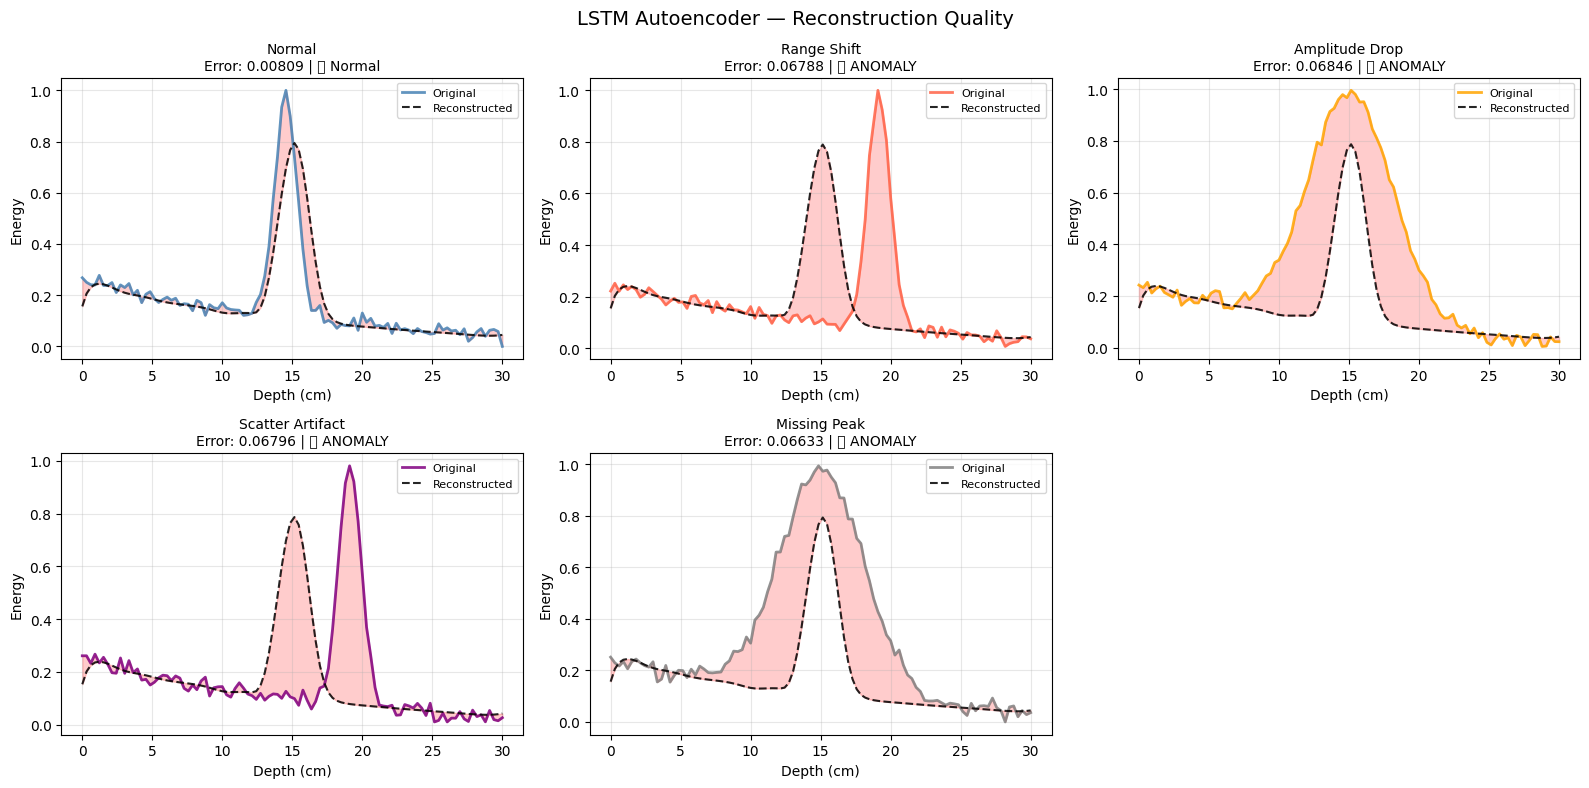

In [19]:
depth = np.linspace(0, 30, 100)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('LSTM Autoencoder — Reconstruction Quality', 
             fontsize=14)

# One example per class
examples = [
    ('Normal',           X_val_3d[0:1],         'steelblue'),
    ('Range Shift',      X_anomaly_3d[0:1],      'tomato'),
    ('Amplitude Drop',   X_anomaly_3d[250:251],  'orange'),
    ('Scatter Artifact', X_anomaly_3d[500:501],  'purple'),
    ('Missing Peak',     X_anomaly_3d[750:751],  'gray'),
]

for ax, (title, signal, color) in zip(axes.flat, examples):
    recon    = model.predict(signal, verbose=0)
    original = signal[0, :, 0]
    rebuilt  = recon[0, :, 0]
    error    = np.mean((original - rebuilt) ** 2)

    ax.plot(depth, original, color=color,
            linewidth=2, label='Original', alpha=0.85)
    ax.plot(depth, rebuilt, color='black',
            linewidth=1.5, linestyle='--',
            label='Reconstructed', alpha=0.85)
    ax.fill_between(depth, original, rebuilt,
                    alpha=0.2, color='red')

    status = '🚨 ANOMALY' if error > threshold else '✅ Normal'
    ax.set_title(f'{title}\nError: {error:.5f} | {status}',
                 fontsize=10)
    ax.set_xlabel('Depth (cm)')
    ax.set_ylabel('Energy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

In [20]:
print("LSTM AUTOENCODER SUMMARY")
print("-" * 40)
print(f"Framework      : TensorFlow {tf.__version__}")
print(f"Architecture   : LSTM Encoder-Decoder")
print(f"Hidden units   : 64")
print(f"Trained on     : {len(X_train)} normal signals only")
print(f"Threshold      : {threshold:.6f}")
print(f"Precision      : {precision*100:.2f}%")
print(f"Recall         : {recall*100:.2f}%")
print(f"F1-Score       : {f1*100:.2f}%")

LSTM AUTOENCODER SUMMARY
----------------------------------------
Framework      : TensorFlow 2.16.1
Architecture   : LSTM Encoder-Decoder
Hidden units   : 64
Trained on     : 4000 normal signals only
Threshold      : 0.017078
Precision      : 100.00%
Recall         : 100.00%
F1-Score       : 100.00%
